# 9장 실습 — OpenVLA와 OFT: 오픈 웨이트의 표준

**대응 이론** 9장 「OpenVLA와 OFT — 오픈 웨이트의 표준」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 6분)

RT-2 는 웹 지식이 옮겨 온다는 것을 보였지만 가중치를 공개하지 않았고 TPU 클러스터를 요구했다. OpenVLA 는 같은 주장을 **7B 오픈 웨이트로** 재현했다. DINOv2 와 SigLIP 을 붙인 이중 비전 인코더에 Llama-2 를 얹고, Open X-Embodiment 에서 추린 약 97만 궤적으로 학습했다. 단일 A100 에 올라가고 파인튜닝 스크립트가 공개돼 있다는 점이 이 모델을 사실상의 표준으로 만들었다.

그리고 반년 뒤 같은 팀이 OFT 를 내놓았다. 모델을 키우지 않고 **디코딩 방식만 바꿔** LIBERO 평균 성공률을 76.5%에서 97.1%로, 액션 생성 처리량을 26배로 올렸다. 처방은 셋이다.

1. 병렬 디코딩 — 자기회귀를 버린다
2. 액션 청킹 — 한 번에 여러 스텝
3. 연속 액션 + L1 회귀 — 구간 분류를 버린다

이 노트북은 그 셋을 하나씩 켜 가며 무엇이 얼마나 기여하는지 잰다. 마지막으로 LoRA 파인튜닝의 비용을 확인한다.

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1 | threads 4


## 1. 과제와 지표

5장·6장에서 쓴 상태 기반 과제를 그대로 가져오되, 이번에는 **한 스텝이 아니라 8스텝 청크**를 정답으로 둔다. 목표 블록으로 부드럽게 접근하는 궤적이다. 청킹의 효과를 재려면 정답에도 청크가 있어야 한다.

지표는 셋으로 나눈다. 매끄러운 축의 오차, 그리퍼 부호 정확도, 그리고 추론 시간이다. 5장에서 본 대로 그리퍼는 이진 축이라 별도로 봐야 한다.

In [2]:
AD, H, BINS = 7, 8, 256      # 액션 7축, 청크 8스텝, 구간 256개

def make_chunks(n, seed):
    r = np.random.default_rng(seed)
    p = r.uniform(-.8, .8, (n, 2, 2)).astype(np.float32)
    t = r.integers(0, 2, n)
    x = np.concatenate([p.reshape(n, 4), np.eye(2, dtype=np.float32)[t]], 1)
    c = p[np.arange(n), t]
    out = np.zeros((n, H, AD), np.float32)
    for h in range(H):                                  # 목표로 접근하는 궤적
        f = (h + 1) / H
        d = np.hypot(c[:, 0], c[:, 1]) * (1 - f)
        out[:, h] = np.stack([c[:, 0]*(1-f), c[:, 1]*(1-f), -0.15 - 0.5*d,
                              np.zeros(n), np.zeros(n),
                              np.arctan2(c[:, 1], c[:, 0])/np.pi,
                              np.where(d < .4, 1, -1)], 1)
    return torch.tensor(x), torch.tensor(np.clip(out, -1, 1))

X, Y   = make_chunks(8192, 0)
VX, VY = make_chunks(2048, 7)
to_bin = lambda a: ((a.clamp(-1, 1) + 1) / 2 * (BINS - 1)).round().long()
to_act = lambda i: i.float() / (BINS - 1) * 2 - 1
flat   = lambda y, s: y[:, :s].reshape(y.shape[0], -1)

print("조건", tuple(X.shape), "-> 액션 청크", tuple(Y.shape))
print("청크 하나가", H, "스텝 x", AD, "축 =", H*AD, "개 값")

조건 (8192, 6) -> 액션 청크 (8192, 8, 7)
청크 하나가 8 스텝 x 7 축 = 56 개 값


## 2. 세 처방을 하나씩 켠다

네 가지 구성을 만든다. 몸통은 전부 같고 **액션을 내보내는 방식만** 다르다.

- **자기회귀 이산, 청크 없음** — RT-2 방식이다. 토큰을 하나씩 순서대로 뽑는다
- **자기회귀 이산 + 청킹** — 청크만 얹는다. 뽑을 토큰이 8배로 는다
- **병렬 이산 + 청킹** — 청크 전체를 한 번의 forward 로 뽑는다
- **병렬 연속 + 청킹** — 거기에 구간 분류 대신 L1 회귀를 쓴다

In [3]:
class Trunk(nn.Module):
    def __init__(s, h=192):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(6, h), nn.GELU(), nn.Linear(h, h), nn.GELU())
    def forward(s, x): return s.f(x)

class ARDiscrete(nn.Module):          # 자기회귀: 토큰을 하나씩
    def __init__(s, h=192, steps=1):
        super().__init__()
        s.trunk = Trunk(h); s.steps = steps; s.n = steps * AD
        s.tokemb = nn.Embedding(BINS + 1, h)                 # 마지막은 시작 토큰
        s.posemb = nn.Parameter(torch.randn(1, s.n, h) * .02)
        s.rnn = nn.GRU(h, h, batch_first=True)
        s.head = nn.Linear(h, BINS)
    def forward(s, x, tgt):                                   # teacher forcing
        c = s.trunk(x); B = x.shape[0]
        inp = torch.cat([torch.full((B, 1), BINS, dtype=torch.long), tgt[:, :-1]], 1)
        o, _ = s.rnn(s.tokemb(inp) + s.posemb + c[:, None])
        return s.head(o)
    @torch.no_grad()
    def generate(s, x):                                       # n 번의 forward
        c = s.trunk(x); B = x.shape[0]
        prev = torch.full((B, 1), BINS, dtype=torch.long); hid = None; outs = []
        for i in range(s.n):
            o, hid = s.rnn(s.tokemb(prev) + s.posemb[:, i:i+1] + c[:, None], hid)
            prev = s.head(o[:, 0]).argmax(-1, keepdim=True)
            outs.append(prev)
        return torch.cat(outs, 1)

class ParDiscrete(nn.Module):         # 병렬 이산: 한 번에 전부
    def __init__(s, h=192, steps=1):
        super().__init__()
        s.trunk = Trunk(h); s.steps = steps; s.n = steps * AD
        s.head = nn.Linear(h, s.n * BINS)
    def forward(s, x): return s.head(s.trunk(x)).view(-1, s.n, BINS)

class ParContinuous(nn.Module):       # 병렬 연속: L1 회귀
    def __init__(s, h=192, steps=1):
        super().__init__()
        s.trunk = Trunk(h); s.steps = steps; s.n = steps * AD
        s.head = nn.Linear(h, s.n)
    def forward(s, x): return s.head(s.trunk(x))

In [4]:
def run(kind, steps, epochs=1200, lr=3e-3, bs=128, seed=0):
    torch.manual_seed(seed)
    m = {"ar": ARDiscrete, "pd": ParDiscrete, "pc": ParContinuous}[kind](steps=steps)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, epochs, pct_start=.15)
    g = torch.Generator().manual_seed(9); t0 = time.time()
    for i in range(epochs):
        idx = torch.randint(0, len(X), (bs,), generator=g)
        xb, yb = X[idx], flat(Y[idx], steps)
        if   kind == "ar": loss = F.cross_entropy(m(xb, to_bin(yb)).reshape(-1, BINS), to_bin(yb).reshape(-1))
        elif kind == "pd": loss = F.cross_entropy(m(xb).reshape(-1, BINS), to_bin(yb).reshape(-1))
        else:              loss = F.smooth_l1_loss(m(xb), yb, beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    train_s = time.time() - t0
    with torch.no_grad():
        for _ in range(2):                                    # 워밍업
            _ = m.generate(VX[:64]) if kind == "ar" else m(VX[:64])
        t1 = time.time()
        p = (to_act(m.generate(VX)) if kind == "ar" else
             (to_act(m(VX).argmax(-1)) if kind == "pd" else m(VX)))
        infer_ms = (time.time() - t1) / len(VX) * 1000
    P = p.view(-1, steps, AD); T = VY[:, :steps]
    return dict(cont=(P[..., :6] - T[..., :6]).abs().mean().item(),
                grip=((P[..., 6] > 0) == (T[..., 6] > 0)).float().mean().item(),
                ms=infer_ms, train=train_s)

CFG = [("자기회귀 이산, 청크 없음", "ar", 1),
       ("자기회귀 이산 + 청킹",     "ar", H),
       ("병렬 이산 + 청킹",         "pd", H),
       ("병렬 연속 L1 + 청킹",      "pc", H)]
res = {}
for name, k, s in CFG:
    res[name] = run(k, s)
    r = res[name]
    print(f"{name:<26} 연속축 MAE {r['cont']:.4f}  그리퍼 {r['grip']:.0%}  "
          f"추론 {r['ms']:.3f}ms  학습 {r['train']:.0f}s")

자기회귀 이산, 청크 없음             연속축 MAE 0.0145  그리퍼 98%  추론 0.010ms  학습 6s
자기회귀 이산 + 청킹               연속축 MAE 0.0152  그리퍼 98%  추론 0.144ms  학습 50s
병렬 이산 + 청킹                 연속축 MAE 0.0133  그리퍼 99%  추론 0.020ms  학습 12s
병렬 연속 L1 + 청킹              연속축 MAE 0.0194  그리퍼 95%  추론 0.000ms  학습 1s


자기회귀 이산 + 청킹               연속축 MAE 0.0154  그리퍼 98%  추론 0.259ms  학습 170s


병렬 이산 + 청킹                 연속축 MAE 0.0133  그리퍼 99%  추론 0.065ms  학습 40s


병렬 연속 L1 + 청킹              연속축 MAE 0.0194  그리퍼 95%  추론 0.001ms  학습 2s


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

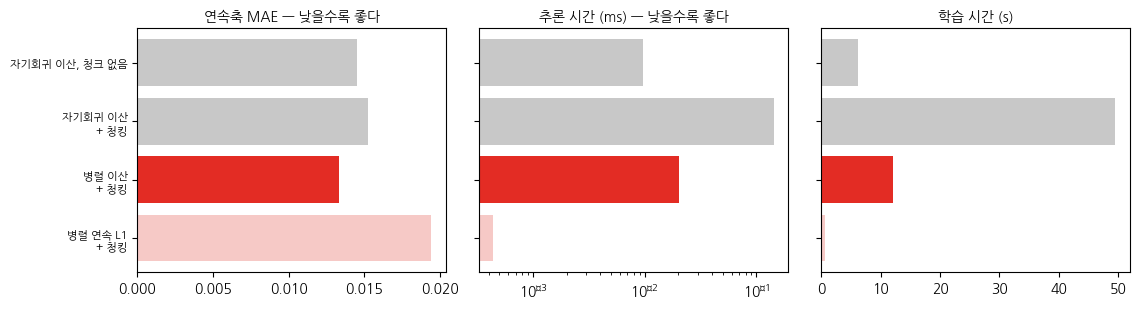

청킹의 대가 (자기회귀): 추론 14.9배 증가
자기회귀 -> 병렬 (청킹 유지): 추론 7.1배, 학습 4.1배 빨라진다


In [6]:
names = [c[0] for c in CFG]
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.2))
cols = [GREY, GREY, RED, PINK]
ax[0].barh(range(4), [res[n]["cont"] for n in names], color=cols)
ax[0].set_title("연속축 MAE — 낮을수록 좋다", fontsize=10)
ax[1].barh(range(4), [res[n]["ms"] for n in names], color=cols)
ax[1].set_title("추론 시간 (ms) — 낮을수록 좋다", fontsize=10); ax[1].set_xscale("log")
ax[2].barh(range(4), [res[n]["train"] for n in names], color=cols)
ax[2].set_title("학습 시간 (s)", fontsize=10)
for a in ax:
    a.set_yticks(range(4)); a.invert_yaxis()
ax[0].set_yticklabels([n.replace(" + ", "\n+ ") for n in names], fontsize=8)
for a in ax[1:]: a.set_yticklabels([])
plt.tight_layout(); plt.show()

ar_chunk, par_chunk = res[names[1]], res[names[2]]
print(f"청킹의 대가 (자기회귀): 추론 {res[names[1]]['ms']/res[names[0]]['ms']:.1f}배 증가")
print(f"자기회귀 -> 병렬 (청킹 유지): 추론 {ar_chunk['ms']/par_chunk['ms']:.1f}배, "
      f"학습 {ar_chunk['train']/par_chunk['train']:.1f}배 빨라진다")

## 3. LoRA — 4%의 파라미터로 파인튜닝한다

OpenVLA 가 사실상의 표준이 된 데는 가중치 공개만큼이나 **파인튜닝이 현실적이라는 점**이 컸다. 7B 모델을 통째로 학습시키면 옵티마이저 상태까지 80GB 를 넘기지만, LoRA 를 쓰면 24GB 한 장으로 내려온다.

원리는 간단하다. 원래 가중치는 얼려 두고, 옆에 낮은 계수 행렬 두 개를 붙여 그것만 학습한다.

In [7]:
class LoRALinear(nn.Module):
    def __init__(s, base, r=8, alpha=16):
        super().__init__()
        s.base = base
        for p in s.base.parameters(): p.requires_grad_(False)   # 원래 가중치는 얼린다
        s.A = nn.Parameter(torch.randn(r, base.in_features) * 0.01)
        s.B = nn.Parameter(torch.zeros(base.out_features, r))    # 0 으로 시작 = 항등
        s.scale = alpha / r
    def forward(s, x):
        return s.base(x) + F.linear(F.linear(x, s.A), s.B) * s.scale

def pretrain(epochs=1200, lr=3e-3, bs=128, seed=0):
    torch.manual_seed(seed); m = ParDiscrete(steps=H)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, epochs, pct_start=.15)
    g = torch.Generator().manual_seed(9)
    for i in range(epochs):
        idx = torch.randint(0, len(X), (bs,), generator=g)
        xb, yb = X[idx], flat(Y[idx], H)
        loss = F.cross_entropy(m(xb).reshape(-1, BINS), to_bin(yb).reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

FX, FY = make_chunks(2048, 55)        # 새 환경에서 모은 소량의 시연

def finetune(m, mode, epochs=600, lr=1e-3, bs=64):
    if mode == "lora":
        for p in m.parameters(): p.requires_grad_(False)
        m.head        = LoRALinear(m.head, r=8)
        m.trunk.f[0]  = LoRALinear(m.trunk.f[0], r=8)
        m.trunk.f[2]  = LoRALinear(m.trunk.f[2], r=8)
    ps = [p for p in m.parameters() if p.requires_grad]
    n_train = sum(p.numel() for p in ps); n_all = sum(p.numel() for p in m.parameters())
    opt = torch.optim.AdamW(ps, lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, epochs, pct_start=.15)
    g = torch.Generator().manual_seed(3); t0 = time.time()
    for i in range(epochs):
        idx = torch.randint(0, len(FX), (bs,), generator=g)
        xb, yb = FX[idx], flat(FY[idx], H)
        loss = F.cross_entropy(m(xb).reshape(-1, BINS), to_bin(yb).reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    with torch.no_grad():
        p = to_act(m(VX).argmax(-1)).view(-1, H, AD)
    return n_train, n_all, (p[..., :6] - VY[:, :H, :6]).abs().mean().item(), time.time() - t0

print(f"{'파인튜닝':<12}{'학습 파라미터':>16}{'비율':>9}{'연속축 MAE':>12}{'시간':>8}")
print("-" * 60)
for mode in ("full", "lora"):
    m = pretrain()
    n, tot, mae, t = finetune(m, mode)
    print(f"{mode:<12}{n:>16,}{n/tot:>9.1%}{mae:>12.4f}{t:>7.0f}s")

파인튜닝                 학습 파라미터       비율     연속축 MAE      시간
------------------------------------------------------------
full               2,805,248   100.0%      0.0131      4s
lora                 120,880     4.1%      0.0125      3s


full               2,805,248   100.0%      0.0131     27s


lora                 120,880     4.1%      0.0125     12s



### 다음 장으로

OFT 는 이산 토큰이라는 틀 안에서 디코딩을 고쳤다. π0 는 그 틀 자체를 버린다. 사전학습 VLM 옆에 액션 전문가를 따로 두고 플로 매칭으로 연속 청크를 뽑는데, 두 망이 어텐션 키와 값을 공유한다는 점이 설계의 핵심이다. 10장에서 그 구조를 뜯어 본다.